In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm


In [2]:
def f_base(x):
    ans = 100*(x[1] - x[0]**3)**2 + x[1]**2 + x[0]**2
    return ans

def g_base(x):
    dx1 = 2*x[0] + 600*x[0]**5 - 600*x[1]*x[0]**2
    dx2 = 202*x[1] - 200*x[0]**3
    
    dx = np.array((dx1, dx2), dtype=float)
    if np.linalg.norm(dx) > 1e3: #нормирование, если градиент слишком большой
        dx = dx / np.linalg.norm(dx) * 1e3
    return dx

def H_base(x):
    x1x1 = 2 + 3000*x[0]**4 - 1200*x[1]*x[0]
    x1x2 = -600*x[0]**2
    x2x1 = -600*x[0]**2
    x2x2 = 202
    return np.array([[x1x1, x1x2], [x2x1, x2x2]])

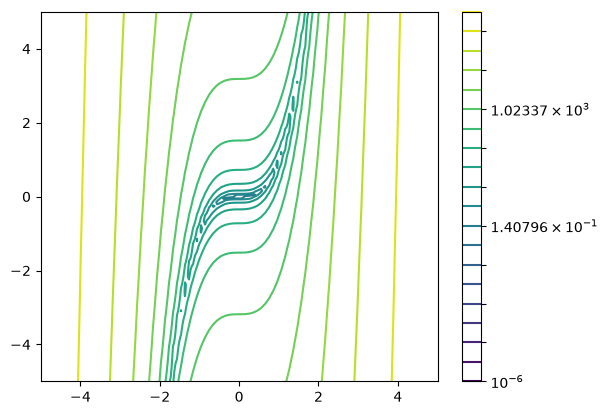

In [3]:

x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = f_base((X, Y))

Z_log = Z - Z.min() + 1e-6

levels = np.logspace(np.log10(Z_log.min()), np.log10(Z_log.max()), 20)

plt.contour(X, Y, Z_log, levels=levels, norm=LogNorm())
plt.colorbar()
plt.show()

In [4]:
# Метод ускоренного градиентного спуска Нестерова
def method_1(eps, start, alpha=1e-3, beta = 0.9):
    iter_c = 0
    f_call_c = 0

    def f(x):
        nonlocal f_call_c
        f_call_c += 1
        return f_base(x)

    def g(x):
        nonlocal f_call_c
        f_call_c += 1
        return g_base(x)

    p_x = np.array(start, dtype=float)
    p_dx = g(p_x)
    # print(p_dx)
    run = [p_x] 

    x = p_x - p_dx * alpha 
    dx = g(x) 
    run.append(x)
    # print(run)

    while np.linalg.norm(dx) > eps:
        iter_c += 1
        beta = (iter_c - 1)/(iter_c + 2)

        y = x + beta * (x - p_x)
        # if(iter_c % 10000 == 1):
        #     print(y)
        dy = g(y)

        p_x = x
        p_dx = dx

        x = y - alpha * dy
        dx = g(x)
        run.append(x)

        # if(iter_c % 10000 == 1):
        #     print(x)
    return (x, f(x), iter_c, f_call_c, run)

In [5]:
# Метод Бройдена
def method_2(eps, start, alpha=1e-3):
    iter_c = 0
    f_call_c = 0

    def f(x):
        nonlocal f_call_c
        f_call_c += 1
        return f_base(x)

    def g(x):
        nonlocal f_call_c
        f_call_c += 1
        return g_base(x)

    
    x = np.array(start, dtype=float)
    dx = g(x)

    H = np.eye(2)

    while np.linalg.norm(dx) > eps:
        # iter_c += 1
        # p = -H @ dx

        # x_n = x + alpha * p
        # dx_n = g(x_n)

        # s = x_n - x
        # y = dx_n - dx

        # Hy = H @ y          # = H y
        # Hs = H @ s          # = H s

        # denominator = float(np.dot(s, Hs))   # s^T H s

        # if abs(denominator) > 1e-12:
        #     H = H + np.outer(s - Hy, Hs) / denominator

        # x = x_n
        # dx = dx_n
        
    return (x, f(x), iter_c, f_call_c, run)

IndentationError: expected an indented block after 'while' statement on line 22 (217387230.py, line 43)

In [ ]:
eps = 1e-6
runs = []
mt_runs = []
for (x, y) in ((1, 1), (10, 0), (-5, -3)):
    (x, f, iter_c, f_call_c, run) = method_1(eps, (x, y))
    print(eps, iter_c, f_call_c, (x[0], x[1]), f)
    mt_runs.append(run)
    
runs.append(mt_runs)
print()

for (x, y) in ((1, 1), (10, 0), (-5, -3)):
    (x, f, iter_c, f_call_c, run) = method_2(eps, (x, y))
    print(eps, iter_c, f_call_c, (x[0], x[1]), f)
    mt_runs.append(run)

1e-06 2407 4817 (np.float64(7.135848532804089e-08), np.float64(8.051694949315103e-15)) 5.092033428318774e-15
1e-06 1988 3979 (np.float64(-1.4808834606083124e-07), np.float64(2.6644470644298122e-14)) 2.1930158239104215e-14
1e-06 1341 2685 (np.float64(1.6904001559446107e-07), np.float64(-4.955991260101915e-14)) 2.857452687242372e-14



KeyboardInterrupt: 

TypeError: f_base() takes 1 positional argument but 2 were given

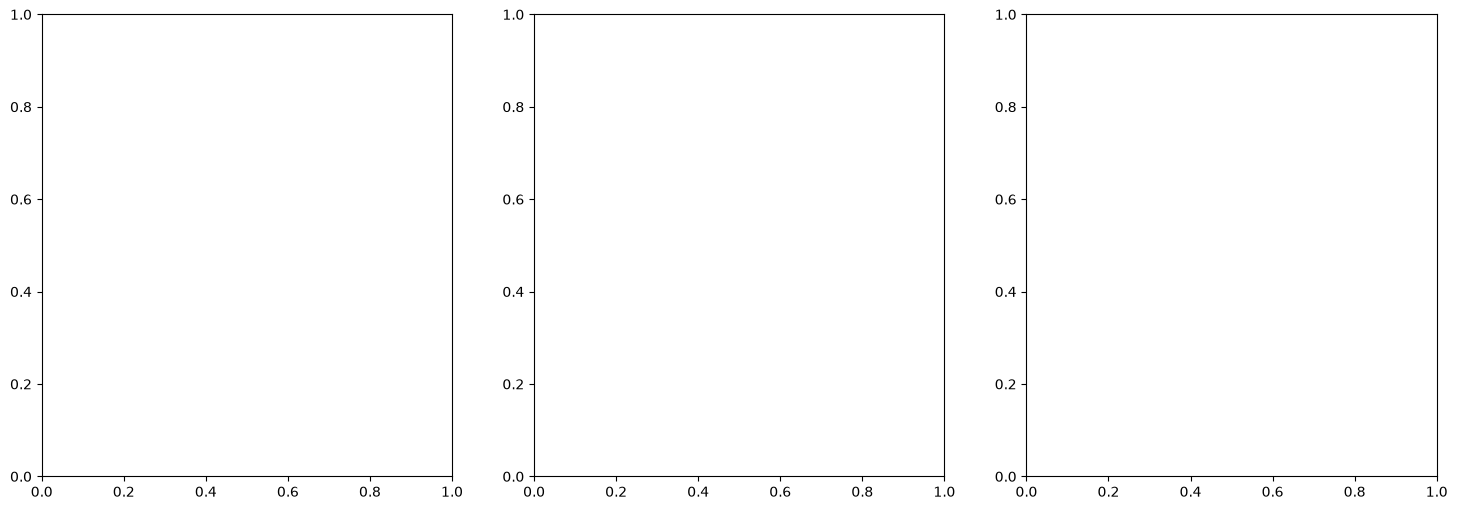

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

ranges = [
    (-2, 2, -2, 2),
    (-1, 11, -1, 11),
    (-6, 2, -6, 2)
]

for i, (ax, run, (x_min, x_max, y_min, y_max)) in enumerate(
    zip(axes, runs, ranges)
):
    # Grid for this subplot
    x = np.linspace(x_min, x_max, 200)
    y = np.linspace(y_min, y_max, 200)
    X, Y = np.meshgrid(x, y)

    Z = f_base((X, Y))

    # Shift because log scale requires positive values
    Z_log = Z - Z.min() + 1e-6

    levels = np.logspace(
        np.log10(Z_log.min()),
        np.log10(Z_log.max()),
        20
    )

    # Contour plot
    ax.contour(
        X, Y, Z_log,
        levels=levels,
        norm=LogNorm()
    )

    # Trajectory
    x_path = [point[0] for point in run]
    y_path = [point[1] for point in run]

    ax.plot(
        x_path,
        y_path,
        marker='o',
        color='red'
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    ax.set_xlabel("x₁")
    ax.set_ylabel("x₂")
    ax.set_title(f"Run {i + 1}")
    ax.grid(True)

plt.tight_layout()
plt.show()